# 03 · Recommender Signal EDA

**Purpose.** Quantify the behavioral signals that determine the design of the
two-stage recommender: which candidate generators earn their place, which
features the ranker needs, and which households are modelable. Every section
below answers a design question — findings feed `reports/eda_report.md` and
the candidate-generation configs.

| # | Design question | Statistic | Decision it drives |
|---|---|---|---|
| 1 | How much purchasing is *repeat* vs *discovery*? | repeat share of lines / baskets | weight of the buy-again generator vs CF |
| 2 | How concentrated is demand? | top-N product share of revenue & lines | popularity candidates, de-biasing needs |
| 3 | Do products have purchase rhythms? | inter-purchase (reorder) interval distributions | reorder-interval features in the ranker |
| 4 | Who can we model? | active households & history depth per snapshot date | snapshot population filter, cold-start policy |

**Conventions.** Time is the integer day index 1–711 (no calendar dates).
Snapshot dates come from `configs/base.yaml`. All queries hit `staging` views
(never `raw`) through a **read-only** connection, so this notebook can run
alongside DBeaver and the pipeline.

In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

# --- repo root (works from notebooks/00_eda/ or the repo root) ---
ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parents[1]

# --- config: single source of truth for dates/horizons ---
CFG = yaml.safe_load((ROOT / "configs" / "base.yaml").read_text())

# --- read-only DB connection + one-line query helper ---
con = duckdb.connect((ROOT / "db" / "retail.duckdb").as_posix(), read_only=True)

def q(sql: str) -> pd.DataFrame:
    """Run SQL against retail.duckdb and return a pandas DataFrame."""
    return con.sql(sql).df()

# --- plotting defaults ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.5)

# --- sanity echo: fail loudly here, not three sections later ---
print("day range :", q("SELECT MIN(day_no) lo, MAX(day_no) hi FROM staging.stg_transactions").iloc[0].tolist())
print("snapshots :", CFG["snapshots"], "| horizon:", CFG["label_horizon_days"])

day range : [1, 711]
snapshots : {'train': [450, 510, 570], 'valid': 600, 'test': 650} | horizon: 30


## 1 · Repeat vs discovery

Does this business run on customers re-buying the same items (grocery-like) or
constantly trying new ones? The answer sets the weight of the *buy-again*
candidate generator — and the bar every fancier model must clear.

In [4]:
repeat_summary = q("""
    WITH pair_counts AS (
        SELECT household_key, product_id, COUNT(DISTINCT basket_id) AS times_bought
        FROM staging.stg_transactions
        GROUP BY household_key, product_id
    )
    SELECT
        AVG(CASE WHEN times_bought > 1 THEN 1.0 ELSE 0 END) AS pairs_repeated_share,
        SUM(times_bought - 1) * 1.0 / SUM(times_bought)     AS purchases_repeat_share
    FROM pair_counts
""")
repeat_summary

,pairs_repeated_share,purchases_repeat_share
0,0.268789,0.460087


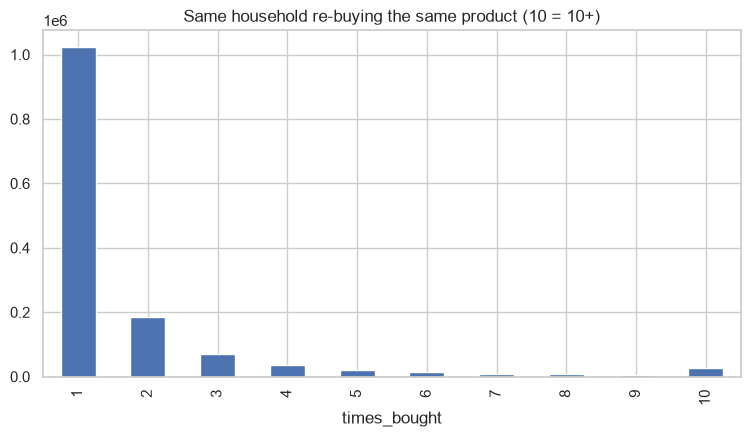

In [5]:
times_bought_dist = q("""
    WITH pair_counts AS (
        SELECT household_key, product_id, COUNT(DISTINCT basket_id) AS times_bought
        FROM staging.stg_transactions
        GROUP BY household_key, product_id
    )
    SELECT LEAST(times_bought, 10) AS times_bought, COUNT(*) AS n_pairs
    FROM pair_counts
    GROUP BY 1 ORDER BY 1
""")
times_bought_dist.set_index("times_bought")["n_pairs"].plot.bar(
    title="Same household re-buying the same product (10 = 10+)")
plt.show()

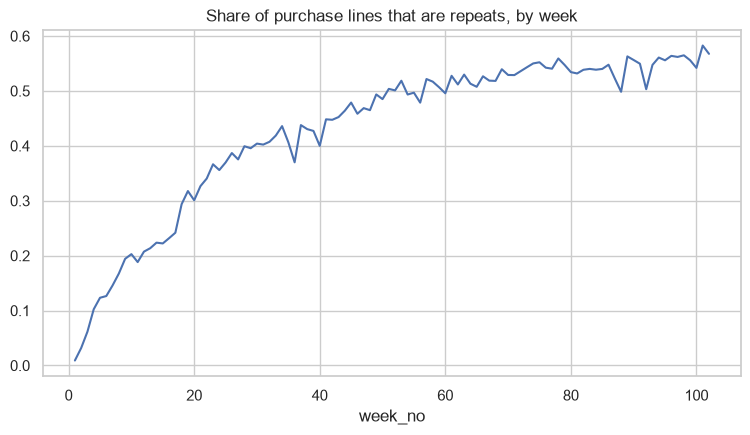

In [6]:
weekly_repeat = q("""
    WITH lines AS (
        SELECT household_key, product_id, week_no,
               ROW_NUMBER() OVER (
                   PARTITION BY household_key, product_id
                   ORDER BY day_no, basket_id
               ) AS nth_purchase
        FROM (SELECT DISTINCT household_key, product_id, basket_id, day_no, week_no
              FROM staging.stg_transactions)
    )
    SELECT week_no,
           AVG(CASE WHEN nth_purchase > 1 THEN 1.0 ELSE 0 END) AS repeat_share
    FROM lines
    GROUP BY week_no ORDER BY week_no
""")
weekly_repeat.set_index("week_no")["repeat_share"].plot(
    title="Share of purchase lines that are repeats, by week")
plt.show()

**Findings — Section 1.** Repeat share plateaus at ~0.55 (all-time 0.46 is
left-censoring artifact; plateau from ~week 60). 73% of household-product
pairs are bought once; the repeated 27% generate over half of volume.
**Decisions:** buy-again generator mandatory (expects ~½ of future purchases);
CF/popularity candidates own the ~45% discovery volume; `times_bought` and
reorder-timing features are priority ranker features; snapshots ≥ day 450 sit
safely in the plateau region.

## 2 · Popularity concentration

How much demand do the top products absorb? Sets the popularity generator's
candidate count, and warns how hard the recommender must fight the
bestseller gravity well (coverage/diversity).

top    10 products -> 4.7% of lines
top   100 products -> 14.8% of lines
top  1000 products -> 36.2% of lines
top  5000 products -> 64.2% of lines


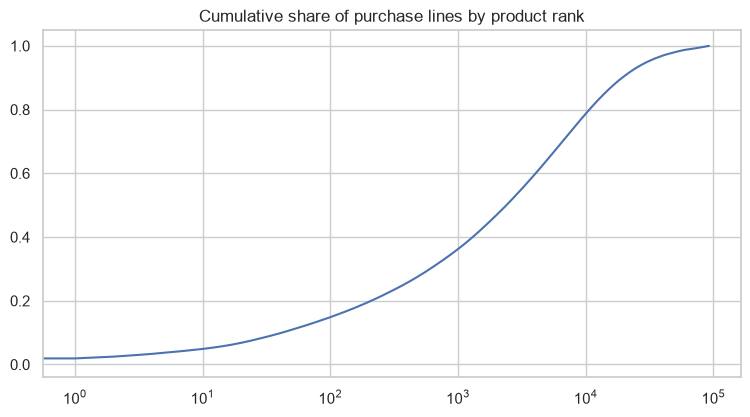

In [7]:
product_popularity = q("""
    SELECT product_id, COUNT(*) AS n_lines
    FROM staging.stg_transactions
    GROUP BY product_id ORDER BY n_lines DESC
""").reset_index(drop=True)

product_popularity["cum_share"] = (
    product_popularity["n_lines"].cumsum() / product_popularity["n_lines"].sum())

for n in [10, 100, 1000, 5000]:
    print(f"top {n:>5} products -> {product_popularity['cum_share'].iloc[n-1]:.1%} of lines")

product_popularity["cum_share"].plot(
    logx=True, title="Cumulative share of purchase lines by product rank")
plt.show()

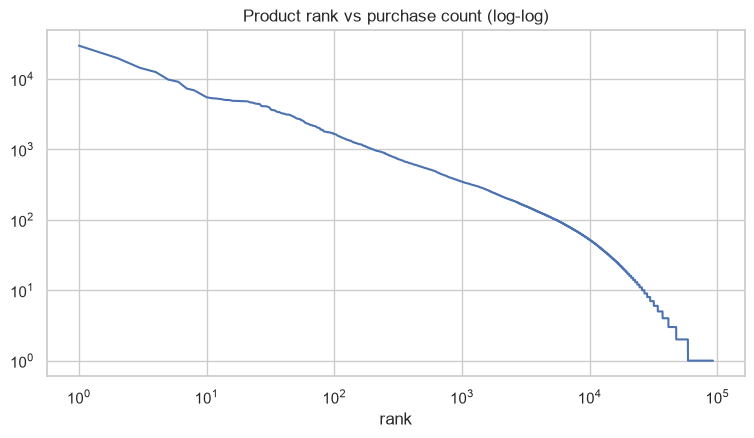

In [8]:
product_popularity["rank"] = product_popularity.index + 1
product_popularity.plot(x="rank", y="n_lines", loglog=True, legend=False,
                        title="Product rank vs purchase count (log-log)")
plt.show()

In [9]:
top_products = q("""
    SELECT s.product_id, p.commodity, p.sub_commodity, s.line_count, s.revenue
    FROM marts.mart_item_stats s
    LEFT JOIN staging.stg_products p USING (product_id)
    ORDER BY s.line_count DESC
    LIMIT 15
""")
top_products

,product_id,commodity,sub_commodity,line_count,revenue
0,1082185,TROPICAL FRUIT,BANANAS,29778,29482.00
1,6534178,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,19820,503867.11
2,1029743,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,14430,41072.06
3,995242,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,12542,26502.46
4,1106523,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,9826,27818.44
5,981760,EGGS,EGGS - X-LARGE,9126,11693.65
6,1133018,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,7315,14942.36
7,883404,BAKED BREAD/BUNS/ROLLS,MAINSTREAM WHITE BREAD,6904,8610.46
8,951590,BAKED BREAD/BUNS/ROLLS,MAINSTREAM WHITE BREAD,6138,12385.27
9,826249,BAKED BREAD/BUNS/ROLLS,HAMBURGER BUNS,5505,6422.52


**Findings — Section 2.** Concentration is moderate: top-10 = 4.7%, top-100 =
14.8%, top-1000 = 36%, top-5000 = 64% of lines — flat head, huge dispersed
tail; tens of thousands of SKUs effectively never sell. Bestsellers are
staples; gasoline is #2 by lines, #1 by revenue (17x bananas), and is
misclassified under COUPON/MISC ITEMS.
**Decisions:** popularity generator localized per department (global head too
small to matter); candidate universe restricted to min-support products;
exclusion list starts with fuel; evaluation will report plain AND
revenue-weighted Recall@K; product hierarchy treated as noisy, not ground truth.

## 3 · Purchase rhythms (reorder intervals)

Products have clocks: milk runs weekly, detergent runs bi-monthly. If gaps
between repeat purchases are structured, then "how overdue is this household
for this product" becomes the ranker's sharpest feature.

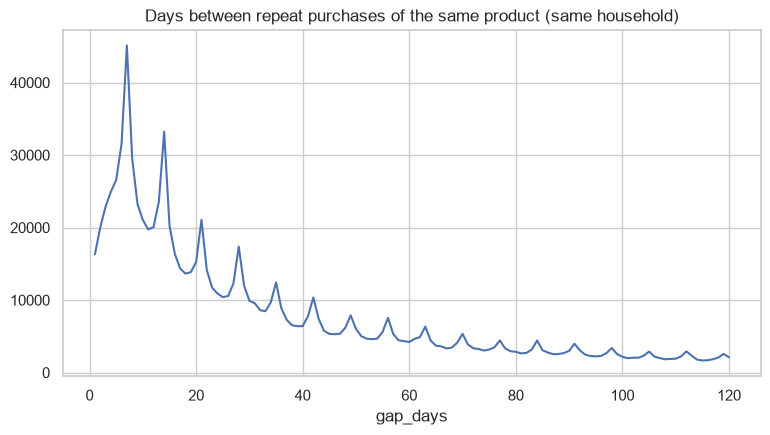

In [10]:
gap_dist = q("""
    WITH purchases AS (
        SELECT DISTINCT household_key, product_id, day_no
        FROM staging.stg_transactions
    ),
    gaps AS (
        SELECT day_no - LAG(day_no) OVER (
                   PARTITION BY household_key, product_id ORDER BY day_no
               ) AS gap_days
        FROM purchases
    )
    SELECT gap_days, COUNT(*) AS n
    FROM gaps
    WHERE gap_days BETWEEN 1 AND 120
    GROUP BY gap_days ORDER BY gap_days
""")
gap_dist.set_index("gap_days")["n"].plot(
    title="Days between repeat purchases of the same product (same household)")
plt.show()

6878 products with 30+ observed gaps


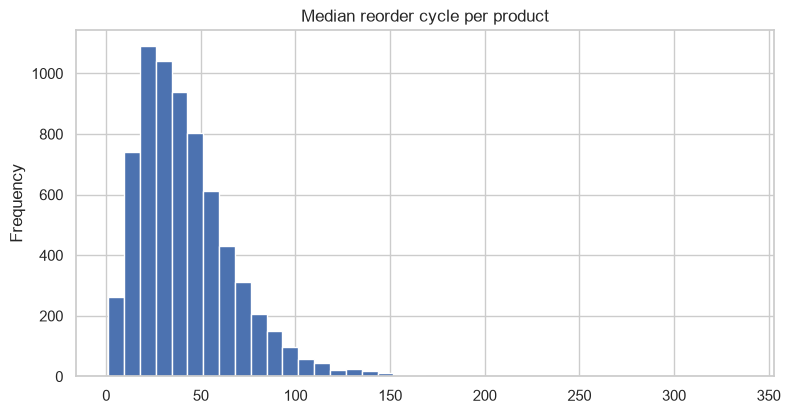

In [11]:
product_cycles = q("""
    WITH purchases AS (
        SELECT DISTINCT household_key, product_id, day_no
        FROM staging.stg_transactions
    ),
    gaps AS (
        SELECT product_id,
               day_no - LAG(day_no) OVER (
                   PARTITION BY household_key, product_id ORDER BY day_no
               ) AS gap_days
        FROM purchases
    )
    SELECT product_id, MEDIAN(gap_days) AS median_gap_days, COUNT(*) AS n_gaps
    FROM gaps
    WHERE gap_days IS NOT NULL
    GROUP BY product_id
    HAVING COUNT(*) >= 30
""")
print(len(product_cycles), "products with 30+ observed gaps")
product_cycles["median_gap_days"].plot.hist(
    bins=40, title="Median reorder cycle per product")
plt.show()

**Findings — Section 3.** Reorder gaps show a strong weekly comb (peaks at
7, 14, 21, ...): re-purchase is trip-driven, so next-basket framing is
empirically correct. 6,878 products have reliable reorder cycles (30+ gaps),
with medians spread ~5–150 days — products carry distinct clocks.
**Decisions:** `due_ness = days_since_last / product_median_gap` becomes a
priority ranker feature; median gaps computed with hierarchical fallback
(product → sub-commodity → commodity → global); trip-cadence features
(weeks since last trip) join the customer snapshot.

## 4 · Modelable population per snapshot

How many households have enough history to score at each as-of date, and how
many buy anything in the label window? Sets the population filter and the
cold-start share.

In [12]:
snapshot_days = CFG["snapshots"]["train"] + [CFG["snapshots"]["valid"], CFG["snapshots"]["test"]]

rows = []
for d in snapshot_days:
    rows.append(q(f"""
        SELECT {d} AS asof_day,
               COUNT(*)                                      AS households_seen,
               COUNT(*) FILTER (WHERE last_day > {d} - 30)   AS active_30d,
               COUNT(*) FILTER (WHERE last_day > {d} - 90)   AS active_90d,
               COUNT(*) FILTER (WHERE n_baskets >= 5)        AS baskets_5plus
        FROM (
            SELECT household_key,
                   MAX(day_no)               AS last_day,
                   COUNT(DISTINCT basket_id) AS n_baskets
            FROM staging.stg_transactions
            WHERE day_no <= {d}
            GROUP BY household_key
        )
    """))
population = pd.concat(rows, ignore_index=True)
population

,asof_day,households_seen,active_30d,active_90d,baskets_5plus
0,450,2498,2020,2297,2415
1,510,2498,2062,2311,2438
2,570,2498,2029,2317,2453
3,600,2498,2060,2311,2460
4,650,2499,2037,2326,2469


In [13]:
rows = []
for d in snapshot_days:
    rows.append(q(f"""
        SELECT {d} AS asof_day,
               COUNT(DISTINCT f.household_key) AS with_history,
               COUNT(DISTINCT l.household_key) AS buying_in_window
        FROM customer_snapshot({d}) f
        LEFT JOIN purchase_labels({d}, 30) l USING (household_key)
    """))
label_rates = pd.concat(rows, ignore_index=True)
label_rates["buy_rate_30d"] = label_rates["buying_in_window"] / label_rates["with_history"]
label_rates

,asof_day,with_history,buying_in_window,buy_rate_30d
0,450,2498,2050,0.820657
1,510,2498,2009,0.804243
2,570,2498,2060,0.824660
3,600,2498,2053,0.821857
4,650,2499,2049,0.819928


**Findings — Section 4.** Population is stable and rich: ~2,500 households
with history at every snapshot, ~92% active in trailing 90d, ~98% with 5+
baskets; 30-day buy rate steady at 0.80–0.82 across all five snapshot dates.
**Decisions:** ranking (what) over propensity (whether) confirmed as the core
problem; score all households with history, with a popularity/content
fallback path designed for the (rare) cold household; environment is
stationary across snapshots → clean temporal validation expected.
**Caveat:** panel is curated frequent shoppers — conclusions generalize to a
loyalty file, not to all customers.

  due_bucket  n_pairs  rebuy_rate_30d
0    a: <0.5    36381        0.280311
1   b: 0.5-1    28219        0.209681
2   c: 1-1.5    24087        0.161789
3   d: 1.5-2    20310        0.119793
4     e: 2-3    34417        0.099108
5     f: 3-5    50711        0.074047
6      g: 5+    99143        0.044179


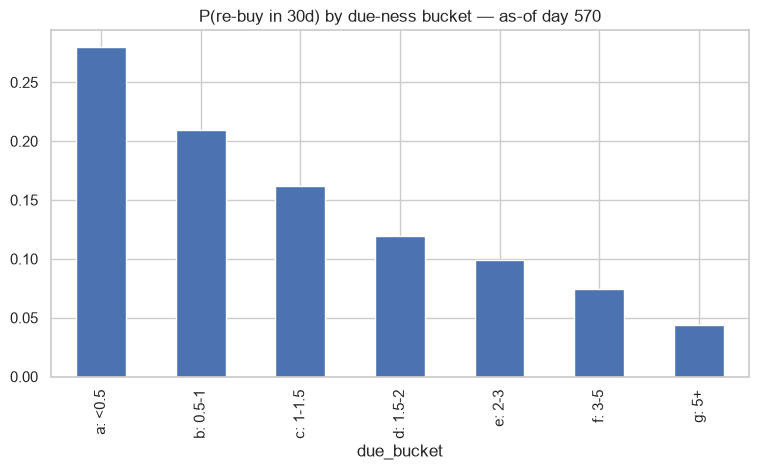

In [14]:
dueness_curve = q("""
    WITH snap AS (
        SELECT * FROM household_product_snapshot(570)
        WHERE times_bought >= 2
    ),
    labels AS (
        SELECT household_key, product_id, 1 AS bought
        FROM purchase_labels(570, 30)
    )
    SELECT
        CASE WHEN due_ness < 0.5 THEN 'a: <0.5'
             WHEN due_ness < 1.0 THEN 'b: 0.5-1'
             WHEN due_ness < 1.5 THEN 'c: 1-1.5'
             WHEN due_ness < 2.0 THEN 'd: 1.5-2'
             WHEN due_ness < 3.0 THEN 'e: 2-3'
             WHEN due_ness < 5.0 THEN 'f: 3-5'
             ELSE 'g: 5+' END AS due_bucket,
        COUNT(*)                  AS n_pairs,
        AVG(COALESCE(bought, 0))  AS rebuy_rate_30d
    FROM snap LEFT JOIN labels USING (household_key, product_id)
    GROUP BY due_bucket ORDER BY due_bucket
""")
print(dueness_curve)
dueness_curve.set_index("due_bucket")["rebuy_rate_30d"].plot.bar(
    title="P(re-buy in 30d) by due-ness bucket — as-of day 570")
plt.show()

**Findings — due-ness curve.** P(re-buy in 30d) declines monotonically in
due-ness (0.28 at <0.5 → 0.044 at 5+): the 30-day window integrates the
hazard, so short-cycle recently-bought pairs dominate — recency is king at
this horizon. **Decisions:** buy-again baseline ranks by recency then
frequency; due_ness retained as ranker feature (strong monotone signal);
conditional hump check (long-cycle products) noted as optional analysis.